# 图表反演

In [9]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

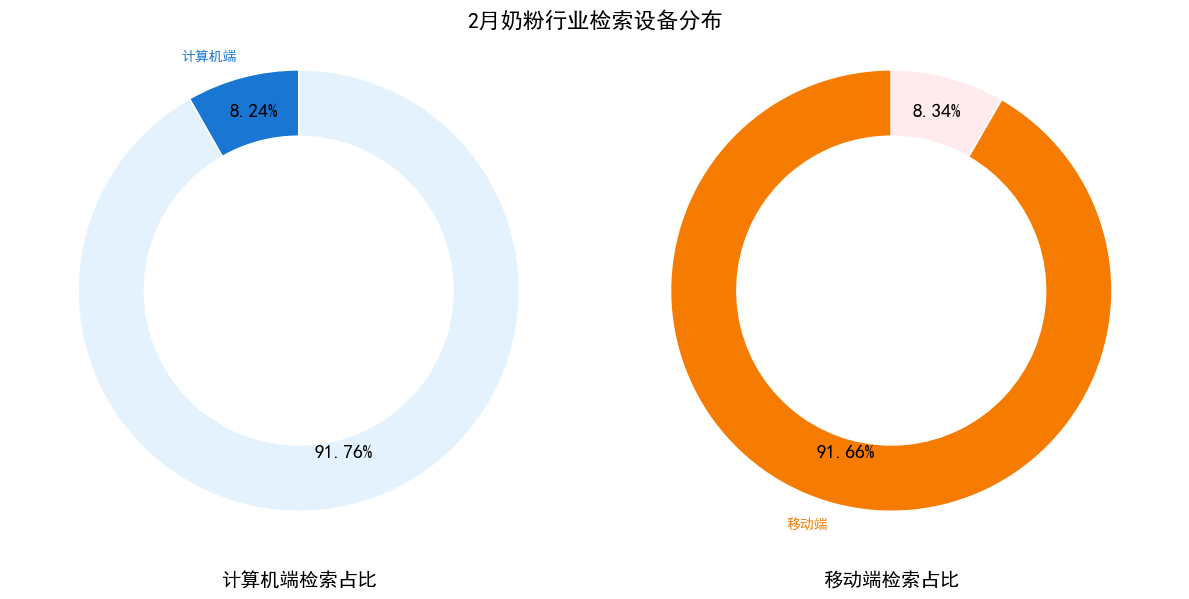

In [10]:
import matplotlib.pyplot as plt

# 数据
sizes = [8.24, 91.66]

# 颜色，更接近原图
computer_colors = ["#1976d2", "#e3f2fd"]  # 计算机端颜色：深蓝色和浅蓝色
mobile_colors = ["#f57c00", "#ffebee"]    # 移动端颜色：橙色和浅橙色

# 创建画布和两个子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.subplots_adjust(top=0.85, bottom=0.15)  # 调整顶部和底部边距

# 绘制计算机端检索占比图（标签颜色调整）
wedges1, texts1, autotexts1 = ax1.pie(
    [sizes[0], 100 - sizes[0]],
    labels=["计算机端", ""],  # 简化标签
    autopct=lambda p: f'{p:.2f}%\n' if p >= 3 else '',
    startangle=90,
    pctdistance=0.8,
    colors=computer_colors,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

# 绘制移动端检索占比图（标签颜色调整）
wedges2, texts2, autotexts2 = ax2.pie(
    [sizes[1], 100 - sizes[1]],
    labels=["移动端", ""],  # 简化标签
    autopct=lambda p: f'{p:.2f}%\n' if p >= 3 else '',
    startangle=90,
    pctdistance=0.8,
    colors=mobile_colors,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

# 设置标签颜色（与对应饼图颜色一致）
for text in texts1:
    text.set_color(computer_colors[0])  # 计算机端标签颜色为深蓝色
for text in texts2:
    text.set_color(mobile_colors[0])    # 移动端标签颜色为深橙色

# 设置百分比文本颜色为黑色
for text in autotexts1 + autotexts2:
    text.set_color('black')
    text.set_fontsize(14)

# 去除坐标轴，使图表为正圆形
ax1.axis('equal')
ax2.axis('equal')

# 设置小标题（在图表下方）
ax1.text(0.5, -0.1, "计算机端检索占比", 
         ha='center', va='center', transform=ax1.transAxes, fontsize=14)
ax2.text(0.5, -0.1, "移动端检索占比", 
         ha='center', va='center', transform=ax2.transAxes, fontsize=14)

# 设置总标题
fig.suptitle("2月奶粉行业检索设备分布", fontsize=16, fontweight='bold')

plt.tight_layout()  # 调整布局，避免重叠
plt.show()

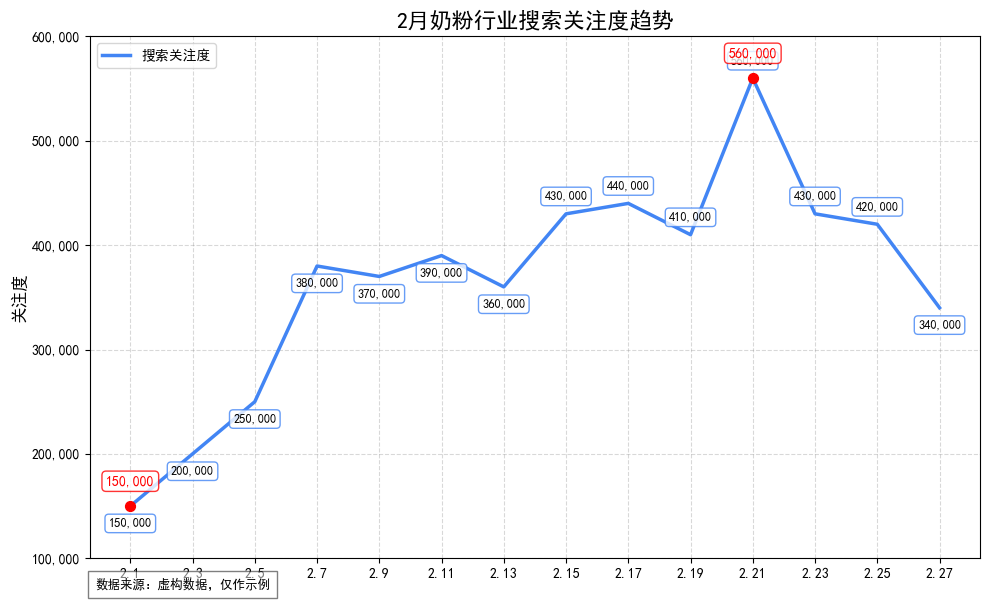

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 构造横轴日期数据，与原图表的日期对应
dates = ["2.1", "2.3", "2.5", "2.7", "2.9", "2.11", 
         "2.13", "2.15", "2.17", "2.19", "2.21", 
         "2.23", "2.25", "2.27"]
# 构造近似原图表趋势的纵轴搜索关注度数据
values = [150000, 200000, 250000, 380000, 370000, 390000, 
          360000, 430000, 440000, 410000, 560000, 
          430000, 420000, 340000]  

# 创建画布，设置尺寸
fig, ax = plt.subplots(figsize=(10, 6))  

# 绘制折线图，设置蓝色线条，调整线宽让视觉效果更贴近
line, = ax.plot(dates, values, color="#4285F4", linewidth=2.5)  

# 设置图表标题，字体加粗
ax.set_title("2月奶粉行业搜索关注度趋势", fontsize=16, fontweight="bold")  

# 设置纵轴标签和范围、刻度
ax.set_ylabel("关注度", fontsize=12)
ax.set_ylim(100000, 600000)  
ax.set_yticks([100000, 200000, 300000, 400000, 500000, 600000])  
# 格式化纵轴刻度显示，加上逗号分隔
ax.set_yticklabels([f"{tick:,}" for tick in ax.get_yticks()])  

# 设置横轴刻度，使用构造的日期数据
ax.set_xticks(dates)  

# 添加网格线，虚线样式，增加图表可读性
ax.grid(linestyle="--", color="gray", alpha=0.3)  

# 在数据点上添加标注
for x, y in zip(dates, values):
    # 格式化数值，添加千位分隔符
    value_str = f"{y:,}"
    
    # 调整标注位置，避免重叠
    if y > 400000:  # 上方标注
        ax.annotate(value_str, 
                    (x, y), 
                    textcoords="offset points",
                    xytext=(0, 10), 
                    ha='center',
                    fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#4285F4", alpha=0.8))
    else:  # 下方标注
        ax.annotate(value_str, 
                    (x, y), 
                    textcoords="offset points",
                    xytext=(0, -15), 
                    ha='center',
                    fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#4285F4", alpha=0.8))

# 突出显示最大值和最小值
max_value = max(values)
min_value = min(values)
for x, y in zip(dates, values):
    if y == max_value or y == min_value:
        ax.scatter(x, y, color='red', s=50, zorder=5)
        ax.annotate(f"{y:,}", 
                    (x, y), 
                    textcoords="offset points",
                    xytext=(0, 15), 
                    ha='center',
                    fontsize=10,
                    fontweight='bold',
                    color='red',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))

# 添加图例
ax.legend([line], ["搜索关注度"], loc='upper left')

# 添加数据来源说明
plt.figtext(0.1, 0.01, '数据来源：虚构数据，仅作示例', ha="left", fontsize=9, bbox={"facecolor":"white", "alpha":0.5, "pad":5})

# 优化布局，避免元素重叠
plt.tight_layout()  

# 显示图表
plt.show()      

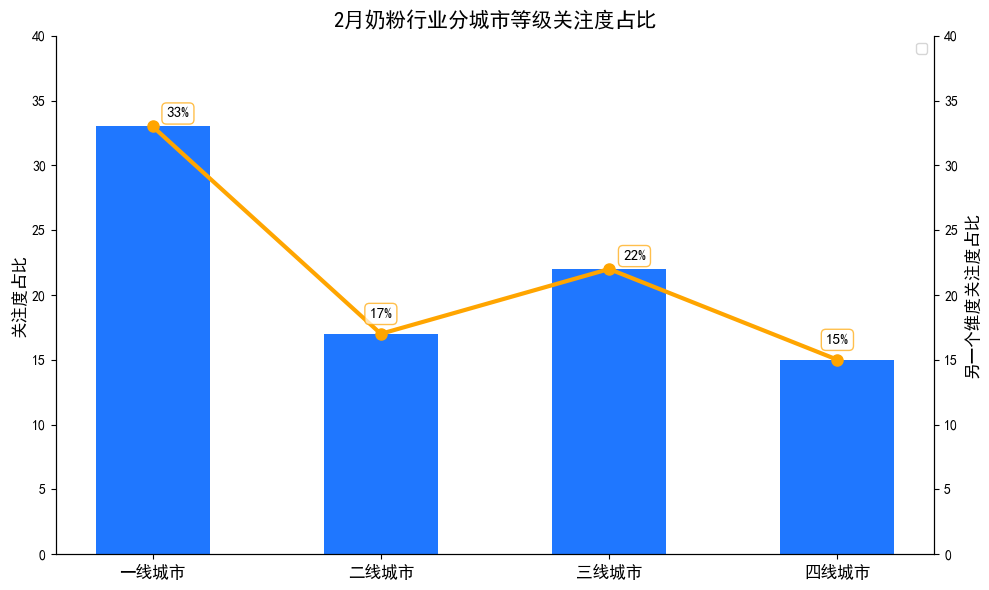

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 城市等级
cities = ['一线城市', '二线城市', '三线城市', '四线城市']
x = np.arange(len(cities))

# 左侧Y轴：柱状图数据（关注度占比）
bar_values = [33, 17, 22, 15]  # 对应左侧坐标轴（0% - 40%）

# 右侧Y轴：折线图数据（另一个维度的关注度占比）
line_values = [33, 17, 22, 15]  # 对应右侧坐标轴（0% - 40%）

fig, ax1 = plt.subplots(figsize=(10, 6))

# 绘制柱状图，左轴
bars = ax1.bar(x, bar_values, color='#1f77ff', width=0.5)
ax1.set_ylabel('关注度占比', fontsize=12)
ax1.set_ylim(0, 40)
ax1.set_yticks(np.arange(0, 41, 5))
ax1.set_xticks(x)
ax1.set_xticklabels(cities, fontsize=12)
ax1.set_title('2月奶粉行业分城市等级关注度占比', fontsize=15)

# 创建右轴绘制折线图
ax2 = ax1.twinx()
line, = ax2.plot(x, line_values, color='orange', linewidth=3, marker='o', markersize=8)
ax2.set_ylabel('另一个维度关注度占比', fontsize=12)
ax2.set_ylim(0, 40)
ax2.set_yticks(np.arange(0, 41, 5))

# 为折线图添加数据标注
for i, (x_val, y_val) in enumerate(zip(x, line_values)):
    # 根据数值大小调整标注位置，避免重叠
    if i in [0, 2]:  # 为避免与柱状图重叠，调整部分标注位置
        ax2.annotate(f'{y_val}%',
                    xy=(x_val, y_val),
                    xytext=(10, 5),  # 向右上偏移
                    textcoords="offset points",
                    ha='left', va='bottom',
                    fontsize=11,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="orange", alpha=0.7))
    else:
        ax2.annotate(f'{y_val}%',
                    xy=(x_val, y_val),
                    xytext=(0, 10),  # 向上偏移
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=11,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="orange", alpha=0.7))

# 美化图形边框
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# 添加图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, ['关注度占比', '另一个维度关注度占比'], loc='upper right')

plt.tight_layout()
plt.show()    

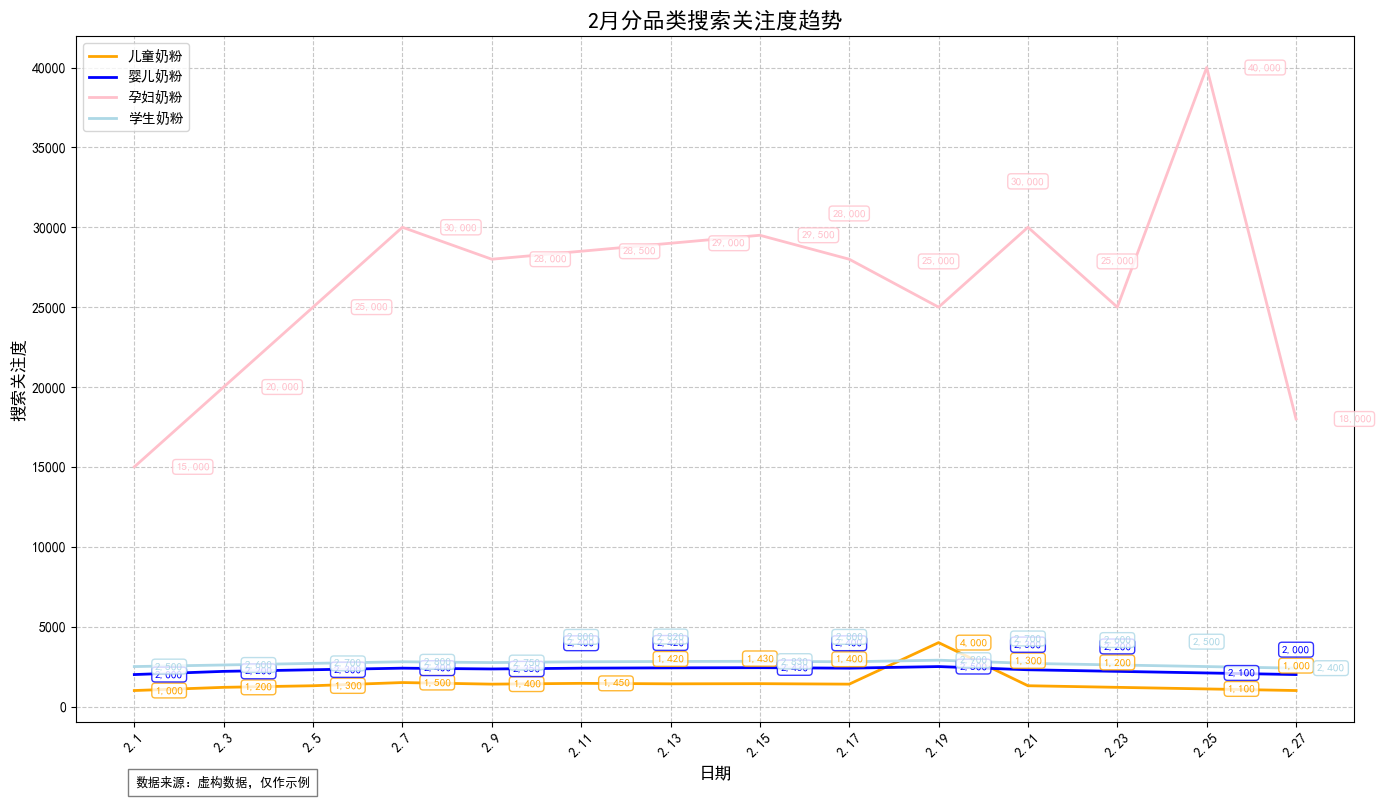

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 日期（x 轴，转换为数字方便绘图，实际显示仍用原始日期）
dates = np.arange(1, 29, 2)
date_labels = ['2.1', '2.3', '2.5', '2.7', '2.9', '2.11', '2.13', '2.15', '2.17', '2.19', '2.21', '2.23', '2.25', '2.27']

# 各类奶粉搜索关注度（y 轴）
children_milk = [1000, 1200, 1300, 1500, 1400, 1450, 1420, 1430, 1400, 4000, 1300, 1200, 1100, 1000]
pregnant_milk = [15000, 20000, 25000, 30000, 28000, 28500, 29000, 29500, 28000, 25000, 30000, 25000, 40000, 18000]
infant_milk = [2000, 2200, 2300, 2400, 2350, 2400, 2420, 2430, 2400, 2500, 2300, 2200, 2100, 2000]
student_milk = [2500, 2600, 2700, 2800, 2750, 2800, 2820, 2830, 2800, 2900, 2700, 2600, 2500, 2400]

# 绘图
plt.figure(figsize=(14, 8))

# 绘制折线图
children_line, = plt.plot(dates, children_milk, color='orange', label='儿童奶粉', linewidth=2)
infant_line, = plt.plot(dates, infant_milk, color='blue', label='婴儿奶粉', linewidth=2)
pregnant_line, = plt.plot(dates, pregnant_milk, color='pink', label='孕妇奶粉', linewidth=2)
student_line, = plt.plot(dates, student_milk, color='lightblue', label='学生奶粉', linewidth=2)

# 设置 x 轴刻度与标签
plt.xticks(dates, date_labels, rotation=45)

# 设置标题、坐标轴标签
plt.title('2月分品类搜索关注度趋势', fontsize=16)
plt.xlabel('日期', fontsize=12)
plt.ylabel('搜索关注度', fontsize=12)

# 添加网格线
plt.grid(True, linestyle='--', alpha=0.7)

# 为数据点添加智能标注，避免重叠
def add_smart_annotations(x, y, color, label, is_pregnant=False):
    """为数据点添加智能标注，避免重叠"""
    # 收集所有已放置的标注位置
    placed_annotations = []
    
    for i, (date, value) in enumerate(zip(x, y)):
        # 格式化数值，添加千位分隔符
        value_str = f"{value:,}"
        
        # 基础偏移量
        base_offset = 15
        
        # 为孕妇奶粉设置更大的基础偏移量
        if is_pregnant:
            base_offset = 30
        
        # 检查是否与已有标注重叠
        overlaps = True
        attempts = 0
        max_attempts = 8
        offset = base_offset
        
        while overlaps and attempts < max_attempts:
            # 尝试不同的角度和距离来放置标注
            angle = (attempts % 4) * 90  # 0, 90, 180, 270 度
            distance = base_offset + (attempts // 4) * 10  # 每两次尝试增加距离
            
            # 计算偏移量
            if angle == 0:  # 右侧
                xytext = (distance, 0)
                ha = 'left'
                va = 'center'
            elif angle == 90:  # 上方
                xytext = (0, distance)
                ha = 'center'
                va = 'bottom'
            elif angle == 180:  # 左侧
                xytext = (-distance, 0)
                ha = 'right'
                va = 'center'
            else:  # 下方
                xytext = (0, -distance)
                ha = 'center'
                va = 'top'
            
            # 检查是否重叠
            overlaps = False
            for (x_annot, y_annot) in placed_annotations:
                # 计算距离
                dist = np.sqrt((date - x_annot)**2 + (value - y_annot)**2)
                # 如果距离太近，认为重叠
                if dist < 30:  # 阈值可以调整
                    overlaps = True
                    break
            
            if not overlaps:
                # 不重叠，记录这个位置
                placed_annotations.append((date + xytext[0]/10, value + xytext[1]/10))
                break
            
            attempts += 1
        
        # 如果尝试多次仍无法找到不重叠的位置，使用默认位置
        if overlaps:
            xytext = (0, base_offset)
            ha = 'center'
            va = 'bottom'
        
        # 添加标注
        plt.annotate(value_str,
                    (date, value),
                    textcoords="offset points",
                    xytext=xytext,
                    ha=ha,
                    va=va,
                    fontsize=8,
                    color=color,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.8))

# 为各类奶粉添加智能标注
add_smart_annotations(dates, children_milk, 'orange', '儿童奶粉')
add_smart_annotations(dates, infant_milk, 'blue', '婴儿奶粉')
add_smart_annotations(dates, pregnant_milk, 'pink', '孕妇奶粉', True)
add_smart_annotations(dates, student_milk, 'lightblue', '学生奶粉')

# 添加图例
plt.legend(fontsize=10, loc='upper left')

# 添加数据来源说明
plt.figtext(0.1, 0.01, '数据来源：虚构数据，仅作示例', ha="left", fontsize=9, bbox={"facecolor":"white", "alpha":0.5, "pad":5})

# 优化布局
plt.tight_layout()

# 显示图表
plt.show()    